# AG-HYPOPT · Trial 07

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Six trials are registered; cell 2 reports `phase = trials` (6/5), so proposals carry expected-improvement (ei) values. **Best = trial_01** (objective 0.1127). All six, with mu travel = `lr_mu*(1 - mu_anneal/2)`:

- **trial_01 (0.1127, best, 0 div):** `lr_mu=0.1551`, `mu_anneal=0.4535`, `lr_gamma=0.7990`, `gamma_anneal=0.2968` (travel 0.120). mu rel-RMSE 77.1%; gamma 21.5%.
- **trial_05 (0.1135, 0 div):** `lr_mu=0.1056`, `mu_anneal=0.3249`, `lr_gamma=0.4648`, `gamma_anneal=0.4530` (travel 0.088). Tied-best region, best mu (56.6%).
- **trial_06 (0.1188, 0 div):** `lr_mu=0.1022`, `mu_anneal=0.3925`, `lr_gamma=0.4058`, `gamma_anneal=0.5330` (travel 0.082); near-duplicate of trial_05, slightly worse.
- **trial_03 (0.1362, 1 div):** travel 0.074, good mu (55.1%), 1nW T05 gamma diverged.
- **trial_04 (0.1418, 1 div):** travel 0.074, damped gamma step, 1nW T05 gamma diverged.
- **trial_02 (0.1449, 1 div):** travel 0.264, worst mu (136%), 1nW T05 gamma diverged.

Patterns: the objective is minimised over a narrow band of small-to-moderate mu travel (trials 01/05/06 at 0.082-0.120, all divergence-free, objectives 0.1127-0.1188); mu rel-RMSE improves as travel shrinks within that band (77% -> 57%); the 1nW T05 gamma cell diverged in every trial except 01, 05 and 06. The stubborn, hyperparameter-insensitive residuals are the high-T mu undershoot (3nW T60/T100 ~-31% / -41% in all low-travel runs) and the low-T gamma under-recovery. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_07'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (6/5 trials)
ID |     ei | params
 1 | 0.9650 | {"gamma_anneal": 0.47579195919520506, "lr_gamma": 0.6466058091634008, "lr_mu": 0.43740895547114966, "mu_anneal": 0.8212284183827663}
 2 | 2.1696 | {"gamma_anneal": 0.24710669480379588, "lr_gamma": 0.31450433149573465, "lr_mu": 0.22531277141191006, "mu_anneal": 0.3685285145518214}
 3 | 2.9494 | {"gamma_anneal": 0.2601390633001819, "lr_gamma": 0.25470380259633885, "lr_mu": 0.08430495675963305, "mu_anneal": 0.34194715881776433}
 4 | 2.6505 | {"gamma_anneal": 0.46339993824423326, "lr_gamma": 0.3770538082068191, "lr_mu": 0.10834352909540013, "mu_anneal": 0.29499413817452547}
 5 | 1.0791 | {"gamma_anneal": 0.6228289087936553, "lr_gamma": 0.4010594950720964, "lr_mu": 0.4158736262518641, "mu_anneal": 0.26759930456378545}
 6 | 3.0709 | {"gamma_anneal": 0.30186251133011566, "lr_gamma": 0.8120366737603734, "lr_mu": 0.11588718218605815, "mu_anneal": 0.3324244871539392}
 7 | 1.1753 | {"gamma_anneal": 0.45683654706350085, "lr_gamma": 0.

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (6 trials), so I rank by expected improvement, then sanity-check each against what the data shows. Candidate travel `lr_mu*(1 - mu_anneal/2)`:
- candidate 6: **ei 3.07** — `lr_mu=0.116`, `mu_anneal=0.332` (travel **0.097**), `lr_gamma=0.812`, `gamma_anneal=0.302`.
- candidate 3: ei 2.95 — `lr_mu=0.084`, `mu_anneal=0.342` (travel 0.070), `lr_gamma=0.255`, `gamma_anneal=0.260`.
- candidate 4: ei 2.65 — `lr_mu=0.108`, `mu_anneal=0.295` (travel 0.092), `lr_gamma=0.377`, `gamma_anneal=0.463`.
- candidate 8: ei 2.37 — `lr_mu=0.094`, `mu_anneal=0.440` (travel 0.074), `lr_gamma=0.355`, `gamma_anneal=0.504`.
- candidate 2: ei 2.17 — `lr_mu=0.225`, `mu_anneal=0.369` (travel 0.184), `lr_gamma=0.315`.

Candidate 6 has the highest ei and is also the most promising point on the evidence: its mu travel (0.097) sits inside the best band (0.082-0.120, where the three best runs live), and its gamma knobs (`lr_gamma=0.812`, `gamma_anneal=0.302`) are almost exactly trial_01's (`0.799` / `0.297`) — the only configuration that ever avoided the low-T gamma divergence on a less-small travel. So candidate 6 combines the good mu region of trials 05/06 with the gamma schedule of the best trial_01, which is precisely the combination not yet tested. The other high-ei candidates are less attractive: candidate 3 pushes travel to 0.070 and `lr_gamma` to 0.255 (both toward/into regions where runs diverged), and candidate 8 also has travel 0.074 with low `lr_gamma`; candidate 2 is at large travel (0.184, the trial_02 direction).

I choose candidate 6 (6 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 6            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.30186251133011566, 'lr_gamma': 0.8120366737603734, 'lr_mu': 0.11588718218605815, 'mu_anneal': 0.3324244871539392}
Running  1nW Trans05 ... 

μ 9.39 -> 11.45 | γ 8.5 -> 4.83 | NLL 1.28


Running  1nW Trans20 ... 

μ 17.32 -> 36.98 | γ 8.5 -> 6.16 | NLL 5.18


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 74.37 | γ 14.1 -> 14.60 | NLL 3.34


Running 3nW Trans100 ... 

μ 175.71 -> 105.84 | γ 14.1 -> 14.34 | NLL 3.19



Total: 8.0 min


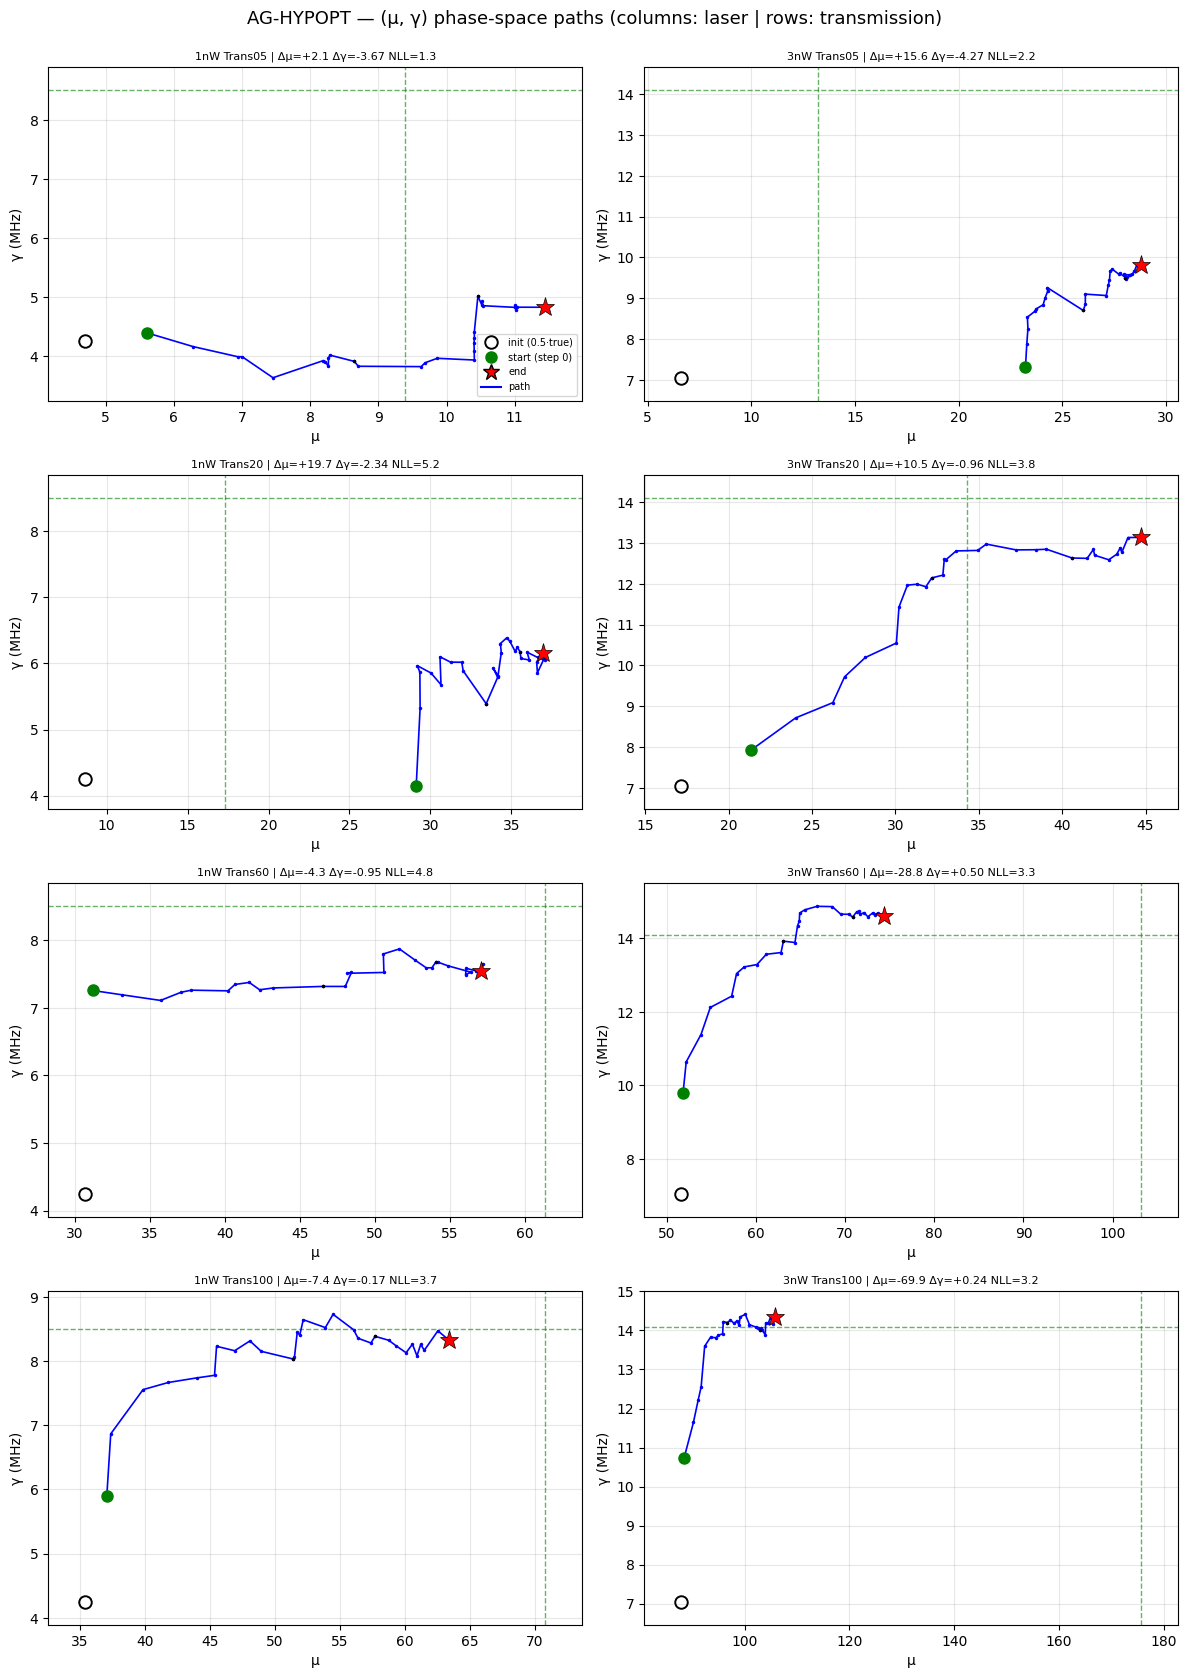

trial finished in 8.0 min
objective = 0.1140 ± 0.0820
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   11.45   +21.9 |     8.50    4.83   -43.2
1nW Trans20       17.32   36.98  +113.5 |     8.50    6.16   -27.5
1nW Trans60       61.37   57.10    -7.0 |     8.50    7.55   -11.2
1nW Trans100       70.82   63.38   -10.5 |     8.50    8.33    -2.0
3nW Trans05       13.20   28.81  +118.2 |    14.10    9.83   -30.3
3nW Trans20       34.28   44.74   +30.5 |    14.10   13.14    -6.8
3nW Trans60      103.20   74.37   -27.9 |    14.10   14.60    +3.6
3nW Trans100      175.71  105.84   -39.8 |    14.10   14.34    +1.7

weighted objective (T-graded, cap=1.0) = 0.1140 | diverged cells: 0
μ: RMSE 28.570 (rel 62.0%, bias -7.827) | γ: RMSE 2.219 (rel 21.6%, bias -1.453)


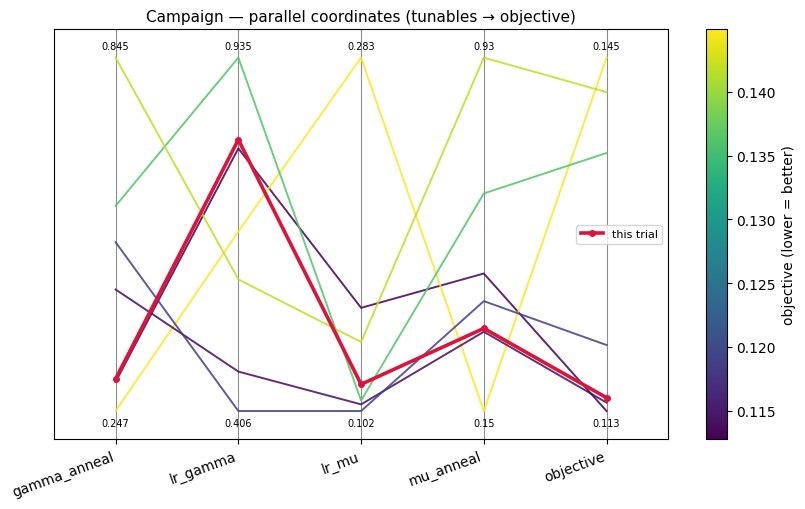

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 07 ran the highest-EI candidate (candidate 6, ei=3.07): `lr_mu=0.1159`, `mu_anneal=0.3324` (effective mu travel 0.097), `lr_gamma=0.8120`, `gamma_anneal=0.3019`. It completed in 8.0 min with objective **0.1140 +/- 0.0820** and **0 diverged cells**. Ranking: trial_01 0.1127 < trial_05 0.1135 < **trial_07 0.1140** < trial_06 0.1188 < trial_03 0.1362 < trial_04 0.1418 < trial_02 0.1449.

Aggregate accuracy: **mu rel-RMSE 62.0%** (RMSE 28.57, bias -7.83); **gamma rel-RMSE 21.6%** (RMSE 2.22, bias -1.45) — essentially tied with trial_01's 21.5% for the campaign's best gamma accuracy, and well ahead of every other low-travel run (trials 05/06 were ~24%).

Per-cell relative errors:
- **mu:** 1nW T05 +21.9%, T20 +113.5%, T60 -7.0%, T100 -10.5% | 3nW T05 +118.2%, T20 +30.5%, T60 -27.9%, T100 -39.8%.
- **gamma:** 1nW T05 -43.2%, T20 -27.5%, T60 -11.2%, T100 -2.0% | 3nW T05 -30.3%, T20 -6.8%, T60 +3.6%, T100 +1.7%.

This was the intended combination — the small-travel mu region (as in trials 05/06) with trial_01's gamma schedule (`lr_gamma~0.81`, `gamma_anneal~0.30`) — and it delivered: the third consecutive divergence-free run, and gamma accuracy essentially tied for best of the campaign (rel-RMSE 21.6%, high-T gamma within ~2-4%). The mu side shows a slightly larger mid-T overshoot than trials 05/06 (3nW T05 +118.2%) but a slightly smaller high-T undershoot (3nW T60 -27.9%), so mu rel-RMSE came out at 62.0% (between trial_05's 56.6% and trial_01's 77.1%). The net objective (0.1140) lands just above trial_01 and trial_05, so the three best runs now form a very tight cluster (0.1127 / 0.1135 / 0.1140).

**Summary:** Trial 07 (lr_mu=0.1159, mu_anneal=0.3324, lr_gamma=0.8120, gamma_anneal=0.3019): objective 0.1140 +/- 0.0820 with 0 diverged cells; combining the small-travel mu region with trial_01's gamma schedule gave gamma accuracy essentially tied for best of the campaign (rel-RMSE 21.6%) and a third straight divergence-free run, landing just behind trial_01/trial_05.
**Key insight:** Trial_01's gamma schedule (`lr_gamma~0.81`, `gamma_anneal~0.30`) reproduces the divergence-free low-T gamma behaviour even when paired with a small mu travel, so gamma stability is a property of the schedule combination rather than of mu travel alone - and the objective now sits in a tight 0.1127-0.1140 cluster.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** Four runs (trials 01, 05, 06, 07) now sit in 0.1127-0.1188 with 0 diverged cells and differ only in the schedule; that flatness means the remaining error is essentially the same in all of them — the high-T mu undershoot (3nW T60/T100 ~-27% to -41%) and the low-T gamma under-recovery (T05/T20 ~-30% to -50%). No combination of the four knobs has moved these, which is the standing motivation for the structural levers already recorded (n_target-adaptive mu step; per-experiment gamma LR); noted only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 07 (lr_mu=0.1159, mu_anneal=0.3324, lr_gamma=0.8120, gamma_anneal=0.3019): objective 0.1140 +/- 0.0820 with 0 diverged cells; combining the small-travel mu region with trial_01's gamma schedule gave gamma accuracy essentially tied with trial_01 for best of the campaign (rel-RMSE 21.6%) and a third straight divergence-free run, landing just behind trial_01/trial_05"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Trial_01's gamma schedule (lr_gamma~0.81, gamma_anneal~0.30) reproduces the divergence-free low-T gamma behaviour even when paired with a small mu travel, so gamma stability is a property of the schedule combination rather than of mu travel alone - and the objective now sits in a tight 0.1127-0.1140 cluster"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_07 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_08.ipynb. Open it and follow its cells from the top.
